In [67]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dila\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dila\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dila\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [69]:
import pandas as pd

sd = pd.read_csv("SD_CWEs.csv", encoding="latin-1")
rc = pd.read_csv("RC_CWEs.csv", encoding="latin-1")
hd = pd.read_csv("HD_CWEs.csv", encoding="latin-1")

df = pd.concat([sd, rc, hd], ignore_index=True)

print("Veri seti boyutu:", df.shape)

print("\nKolonlar:\n", df.columns)

Veri seti boyutu: (1441, 23)

Kolonlar:
 Index(['CWE-ID', 'Name', 'Weakness Abstraction', 'Status', 'Description',
       'Extended Description', 'Related Weaknesses', 'Weakness Ordinalities',
       'Applicable Platforms', 'Background Details', 'Alternate Terms',
       'Modes Of Introduction', 'Exploitation Factors',
       'Likelihood of Exploit', 'Common Consequences', 'Detection Methods',
       'Potential Mitigations', 'Observed Examples', 'Functional Areas',
       'Affected Resources', 'Taxonomy Mappings', 'Related Attack Patterns',
       'Notes'],
      dtype='object')


In [71]:
df = df[['CWE-ID', 'Description']]

df.dropna(inplace=True)

df.head()

,CWE-ID,Description
0,External Control of System or Configuration Se...,Allowing external control of system settings c...
1,Relative Path Traversal,This allows attackers to traverse the file sys...
2,Absolute Path Traversal,This allows attackers to traverse the file sys...
3,Improper Resolution of Path Equivalence,Path equivalence is usually employed in order ...
5,Improper Handling of File Names that Identify ...,Virtual file names are represented like normal...


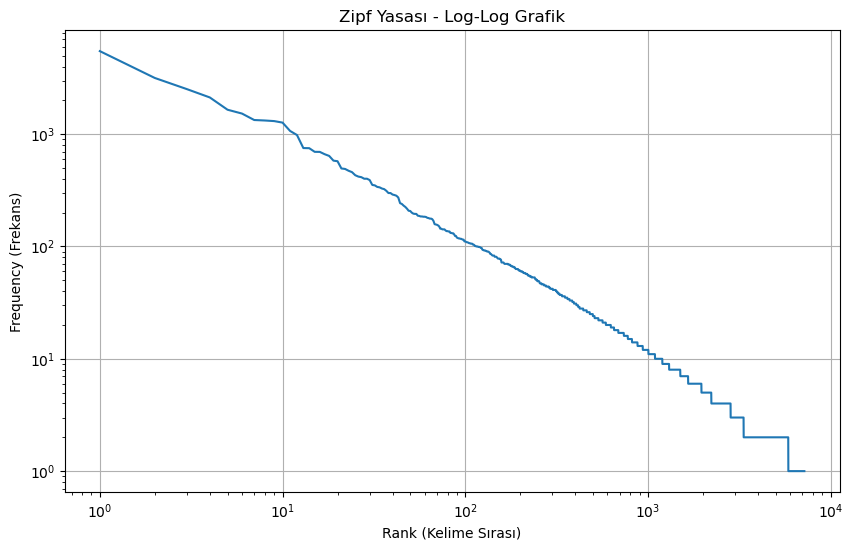

In [73]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

text = " ".join(df['Description'])

words = text.split()

freq = Counter(words)

sorted_freq = sorted(freq.values(), reverse=True)

ranks = np.arange(1, len(sorted_freq)+1)

plt.figure(figsize=(10,6))
plt.loglog(ranks, sorted_freq)
plt.xlabel("Rank (Kelime Sırası)")
plt.ylabel("Frequency (Frekans)")
plt.title("Zipf Yasası - Log-Log Grafik")
plt.grid(True)
plt.show()

In [74]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # HTML
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # özel karakter
    return text

print("ÖNCE:\n", df['Description'][0])

df['clean'] = df['Description'].apply(clean_text)

print("\nSONRA:\n", df['clean'][0])

ÖNCE:
 Allowing external control of system settings can disrupt service or cause an application to behave in unexpected, and potentially malicious ways.

SONRA:
 Allowing external control of system settings can disrupt service or cause an application to behave in unexpected and potentially malicious ways


In [75]:
print("ÖNCE:", df['clean'][0])

df['lower'] = df['clean'].str.lower()

print("SONRA:", df['lower'][0])

ÖNCE: Allowing external control of system settings can disrupt service or cause an application to behave in unexpected and potentially malicious ways
SONRA: allowing external control of system settings can disrupt service or cause an application to behave in unexpected and potentially malicious ways


In [79]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

print("ÖNCE:", df['lower'][0])

df['tokens'] = df['lower'].apply(word_tokenize)

print("SONRA:", df['tokens'][0])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dila\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


ÖNCE: allowing external control of system settings can disrupt service or cause an application to behave in unexpected and potentially malicious ways
SONRA: ['allowing', 'external', 'control', 'of', 'system', 'settings', 'can', 'disrupt', 'service', 'or', 'cause', 'an', 'application', 'to', 'behave', 'in', 'unexpected', 'and', 'potentially', 'malicious', 'ways']


In [81]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print("ÖNCE:", df['tokens'][0])

df['no_stop'] = df['tokens'].apply(
    lambda x: [w for w in x if w not in stop_words]
)

print("SONRA:", df['no_stop'][0])

ÖNCE: ['allowing', 'external', 'control', 'of', 'system', 'settings', 'can', 'disrupt', 'service', 'or', 'cause', 'an', 'application', 'to', 'behave', 'in', 'unexpected', 'and', 'potentially', 'malicious', 'ways']
SONRA: ['allowing', 'external', 'control', 'system', 'settings', 'disrupt', 'service', 'cause', 'application', 'behave', 'unexpected', 'potentially', 'malicious', 'ways']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dila\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [85]:
df[['CWE-ID','lemma']].to_csv("lemmatized_dataset.csv", index=False)
print("CSV dosyaları oluşturuldu!")

CSV dosyaları oluşturuldu!


In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = df['clean']

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(texts)

similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [89]:
import numpy as np

index = 0

scores = list(enumerate(similarity[index]))
sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("En benzer 5 kayıt:")
for i in sorted_scores[1:6]:
    print(i)

En benzer 5 kayıt:
(319, 1.0000000000000002)
(18, 0.23523358212756226)
(382, 0.23523358212756226)
(107, 0.22190457100159572)
(552, 0.22190457100159572)


In [93]:
from nltk.stem import WordNetLemmatizer  

lemmatizer = WordNetLemmatizer()

print("ÖNCE:", df['no_stop'].iloc[0])

df['lemmatized'] = df['no_stop'].apply(
    lambda x: [lemmatizer.lemmatize(w) for w in x]
)

print("SONRA:", df['lemmatized'].iloc[0])

ÖNCE: ['allowing', 'external', 'control', 'system', 'settings', 'disrupt', 'service', 'cause', 'application', 'behave', 'unexpected', 'potentially', 'malicious', 'ways']
SONRA: ['allowing', 'external', 'control', 'system', 'setting', 'disrupt', 'service', 'cause', 'application', 'behave', 'unexpected', 'potentially', 'malicious', 'way']


In [95]:
df['lemmatized'] = df['lemmatized'].apply(lambda x: " ".join(x))

In [101]:

df[['lemmatized']].to_csv("lemmatized_veri.csv",
                         index=False,
                         encoding="utf-8-sig")

print("lemmatized csv hazır")

lemmatized csv hazır


In [107]:
try:
     df[['lemmatized']].to_csv("lemmatized_veri.csv",index=False, encoding="utf-8-sig")    
     print("KAYIT BAŞARILI")
except 